In [1]:
# imports
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import polars.selectors as cs

# sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# for saving data
import pickle

In [2]:
# load data

with open('../data/processed/tableau.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test = data['X_test']
X_train_scaled = data['X_train_scaled']
X_test_scaled = data['X_test_scaled']
y_train = data['y_train']
y_test = data['y_test']
scaler = data['scaler']
imputer = data['imputer']


In [ ]:
# 2a) i) show data
print(X_train.head())
print(y_train.head())

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"Total samples:  {X_train.shape[0] + X_test.shape[0]}")
print(f"Total features: {X_train.shape[1]}")



   HSBASHHD      HSFD001S      HSHO001S      HSHF001S      HSTR001S  \
0     427.0  4.654068e+06  2.142071e+06  1.003646e+06  4.341057e+06   
1     251.0  2.723183e+06  1.330583e+06  7.684718e+05  2.513570e+06   
2     339.0  3.645719e+06  2.087998e+06  1.145372e+06  3.520399e+06   
3     283.0  6.901636e+06  4.021522e+06  1.788680e+06  8.686222e+06   
4     616.0  5.796980e+06  2.387490e+06  1.170575e+06  3.530654e+06   

       HSHC001S      HSPC001S      HSRE001S       HSRO001S      HSTA018S  ...  \
0  1.334128e+06  9.262782e+05  2.147014e+06   95966.653907  1.802264e+06  ...   
1  6.026828e+05  4.216528e+05  1.165109e+06   77466.542677  1.148362e+06  ...   
2  9.994087e+05  5.257407e+05  1.693163e+06  126829.764682  1.257675e+06  ...   
3  2.307600e+06  1.386801e+06  3.571219e+06   76934.598655  2.681197e+06  ...   
4  1.332030e+06  8.757191e+05  2.031181e+06  120102.548051  1.817044e+06  ...   

   ECYGEN1GEN  ECYGEN2GEN  ECYGEN3GEN  ECYTCAHPOP  ECYTCACIT  ECYTCA_U18  \
0       25

In [ ]:
#2a) ii)
#already cleaned cause of data prep
print(f"null values in train: {X_train.isnull().sum()}")
print(f"null values in test: {X_test.isnull().sum()}")
print(f"null values in train scaled: {np.isnan(X_train_scaled).sum()}")
print(f"null values in test scaled: {np.isnan(X_test_scaled).sum()}")

null values in train: HSBASHHD      0
HSFD001S      0
HSHO001S      0
HSHF001S      0
HSTR001S      0
             ..
ECYTCA_U18    0
ECYTCA_18P    0
ECYNCANCIT    0
ECYNCA_U18    0
ECYNCA_18P    0
Length: 1124, dtype: int64
null values in test: HSBASHHD      0
HSFD001S      0
HSHO001S      0
HSHF001S      0
HSTR001S      0
             ..
ECYTCA_U18    0
ECYTCA_18P    0
ECYNCANCIT    0
ECYNCA_U18    0
ECYNCA_18P    0
Length: 1124, dtype: int64
null values in train scaled: 0
null values in test scaled: 0


In [24]:
#2a) iii)
#rows
print({X_train.shape[0]})
#columns
print({X_train.shape[1]})

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

{46348}
{1124}


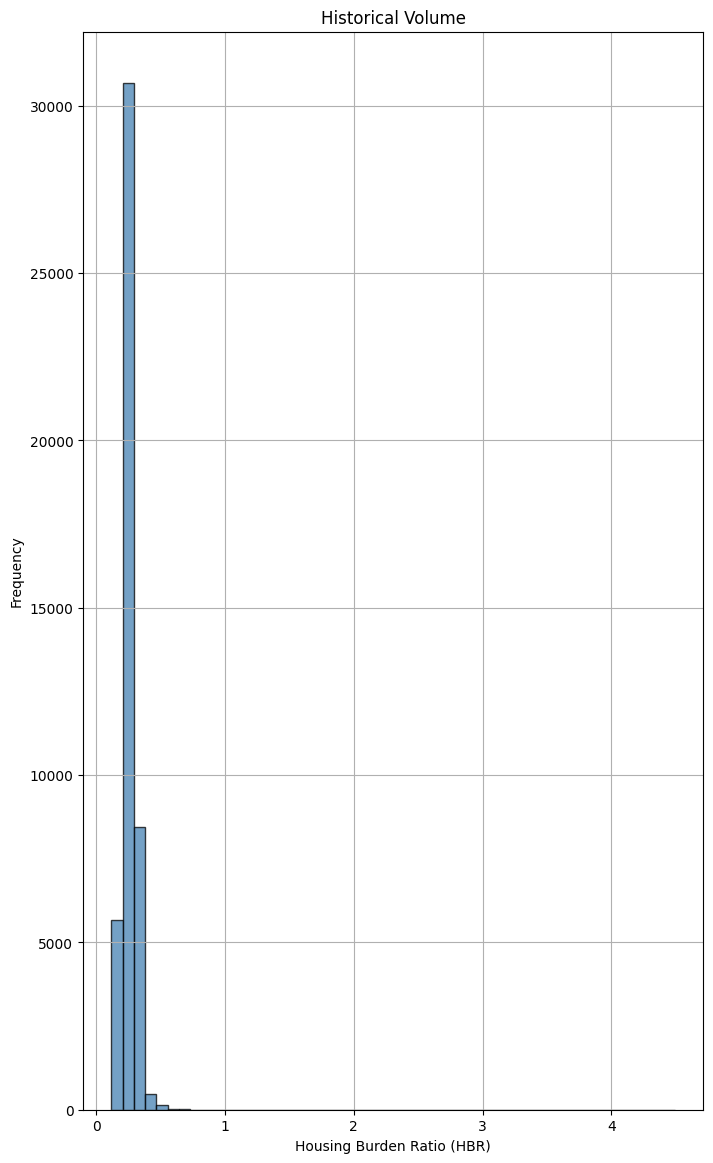

Skewness:  nan
Kurtosis:  nan
Min: 0.11685954117743383 and Max: 4.494179202840323


In [ ]:
#2a) v)
figure, axis = plt.subplots(figsize=(8,14))
axis.hist(y_train, bins=50, edgecolor='black', alpha=0.75, color='steelblue')
axis.set_title("Historical Volume")
axis.set_xlabel("Housing Burden Ratio (HBR)")
axis.set_ylabel("Frequency")
axis.grid(True)

plt.show()

print(f"Min: {y_train.min()} and Max: {y_train.max()}")

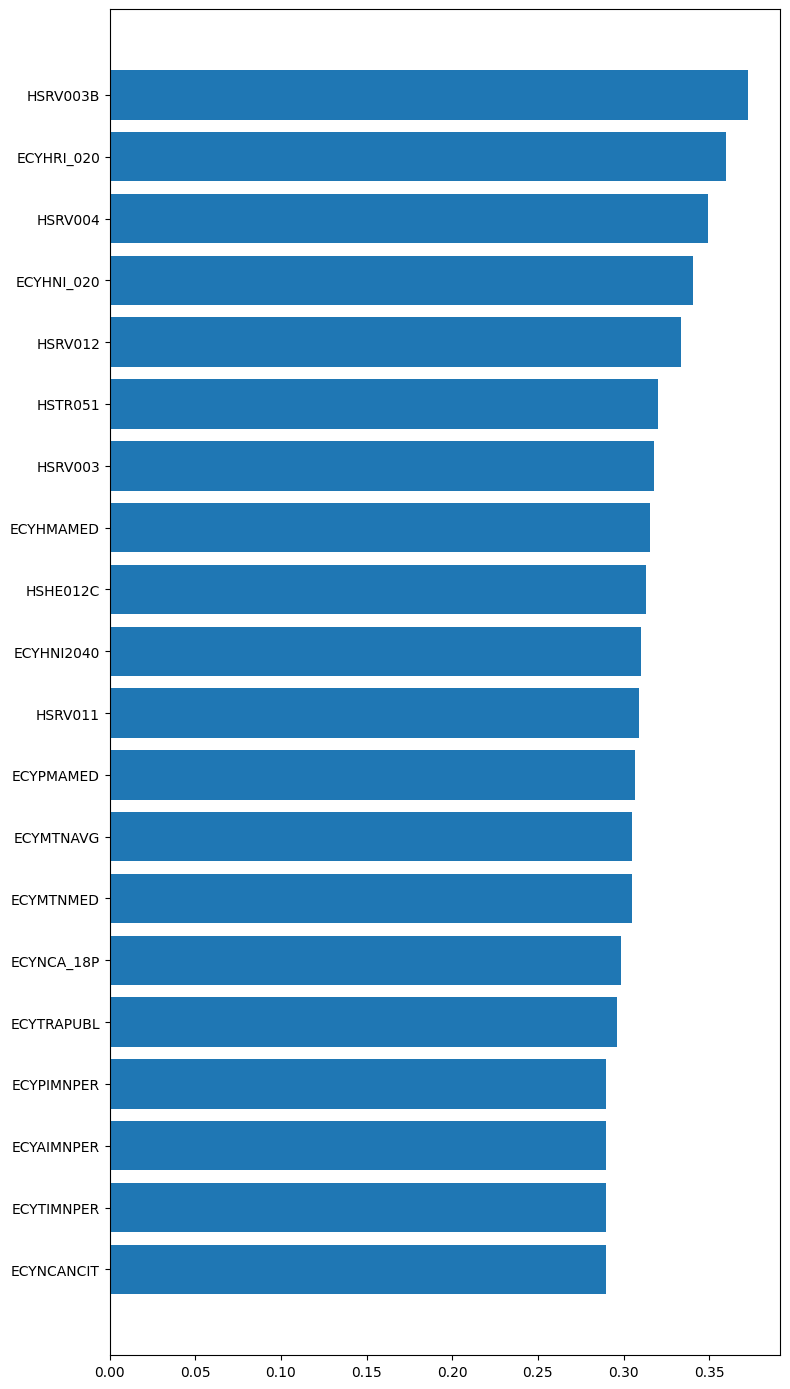


Top 20 correlations:
HSRV003B: -0.37271567807983075
ECYHRI_020: 0.35962477269727294
HSRV004: -0.34940052338822253
ECYHNI_020: 0.34029244721873536
HSRV012: -0.3338187109415687
HSTR051: 0.319976019948024
HSRV003: -0.31778197132879915
ECYHMAMED: -0.3152321359933842
HSHE012C: -0.312930810353859
ECYHNI2040: 0.3099664119621603
HSRV011: -0.30915845662560887
ECYPMAMED: -0.3065683211125846
ECYMTNAVG: -0.30511752697004463
ECYMTNMED: -0.3048690973602671
ECYNCA_18P: 0.2984335635853195
ECYTRAPUBL: 0.29634368651736465
ECYPIMNPER: 0.28983385682756935
ECYAIMNPER: 0.28983385682756935
ECYTIMNPER: 0.28983385682756935
ECYNCANCIT: 0.2895269097896757


In [29]:
# 2a) vi) correlation
correlations = X_train.corrwith(y_train).dropna()
top_20_correlations = correlations.abs().sort_values(ascending=False).head(20)

figure, axis = plt.subplots(figsize=(8, 14))
axis.barh(top_20_correlations.index[::-1], top_20_correlations.values[::-1])

plt.tight_layout()
plt.show()

# print signed values
print("\nTop 20 correlations:")
for feature in top_20_correlations.index:
    print(f"{feature}: {correlations[feature]}")